# ✈️ Flight Delay Analysis — Machine Learning Model

**Goal:** Predict whether a flight will be delayed (>15 min departure delay).

**Model:** Random Forest Classifier  
**Features:** DISTANCE, HOUR, MONTH, DAY_OF_WEEK, AIRLINE_CODE (encoded), ORIGIN (encoded)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

plt.rcParams['figure.dpi'] = 130
sns.set_theme(style='darkgrid')
os.makedirs('../models', exist_ok=True)
PLOT_DIR = '../images/plots'
os.makedirs(PLOT_DIR, exist_ok=True)

print('Loading cleaned data...')
df = pd.read_csv('../data/flights_clean.csv', low_memory=False)
print(f'Shape: {df.shape}')
print(f"Delayed rate: {df['DELAYED'].mean()*100:.1f}%")

Loading cleaned data...
Shape: (2913802, 37)
Delayed rate: 17.5%


In [2]:
# --- Feature Engineering ---
FEATURE_COLS = ['DISTANCE', 'HOUR', 'MONTH', 'DAY_OF_WEEK', 'AIRLINE_CODE', 'ORIGIN']
TARGET_COL = 'DELAYED'

# Subsample to speed up training if dataset is very large (>1.5M rows)
MAX_ROWS = 1_500_000
if len(df) > MAX_ROWS:
    print(f'Subsampling to {MAX_ROWS:,} rows for training speed...')
    df_train_pool = df.sample(MAX_ROWS, random_state=42)
else:
    df_train_pool = df.copy()

# Drop rows where any feature is missing
df_model = df_train_pool[FEATURE_COLS + [TARGET_COL]].dropna()
print(f'Rows after feature NA drop: {len(df_model):,}')

# Label-encode categorical features
le_airline = LabelEncoder()
le_origin = LabelEncoder()

df_model = df_model.copy()
df_model['AIRLINE_CODE'] = le_airline.fit_transform(df_model['AIRLINE_CODE'].astype(str))
df_model['ORIGIN'] = le_origin.fit_transform(df_model['ORIGIN'].astype(str))

print('Encoding complete.')
df_model.head()

Subsampling to 1,500,000 rows for training speed...
Rows after feature NA drop: 1,500,000
Encoding complete.


,DISTANCE,HOUR,MONTH,DAY_OF_WEEK,AIRLINE_CODE,ORIGIN,DELAYED
2413328,250.0,11,4,0,4,372,0
1044032,351.0,12,5,5,16,100,0
374476,177.0,14,10,4,5,180,0
475763,391.0,8,4,6,15,99,0
461581,937.0,14,8,0,2,60,0


In [3]:
# --- Train / Test Split ---
X = df_model[FEATURE_COLS]
y = df_model[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples: {len(X_train):,}')
print(f'Test samples:     {len(X_test):,}')
print(f'Delayed in train: {y_train.mean()*100:.1f}%')
print(f'Delayed in test:  {y_test.mean()*100:.1f}%')

Training samples: 1,200,000
Test samples:     300,000
Delayed in train: 17.6%
Delayed in test:  17.6%


In [4]:
# --- Train Random Forest ---
print('Training RandomForestClassifier...')
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=20,
    n_jobs=-1,
    random_state=42,
    class_weight='balanced'
)
model.fit(X_train, y_train)
print('Training complete ✅')

Training RandomForestClassifier...
Training complete ✅


In [5]:
# --- Evaluate ---
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f'\n=== MODEL EVALUATION ===')
print(f'Accuracy: {acc*100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['On-Time', 'Delayed']))


=== MODEL EVALUATION ===
Accuracy: 65.29%

Classification Report:
              precision    recall  f1-score   support

     On-Time       0.88      0.67      0.76    247314
     Delayed       0.27      0.58      0.37     52686

    accuracy                           0.65    300000
   macro avg       0.58      0.62      0.57    300000
weighted avg       0.77      0.65      0.69    300000



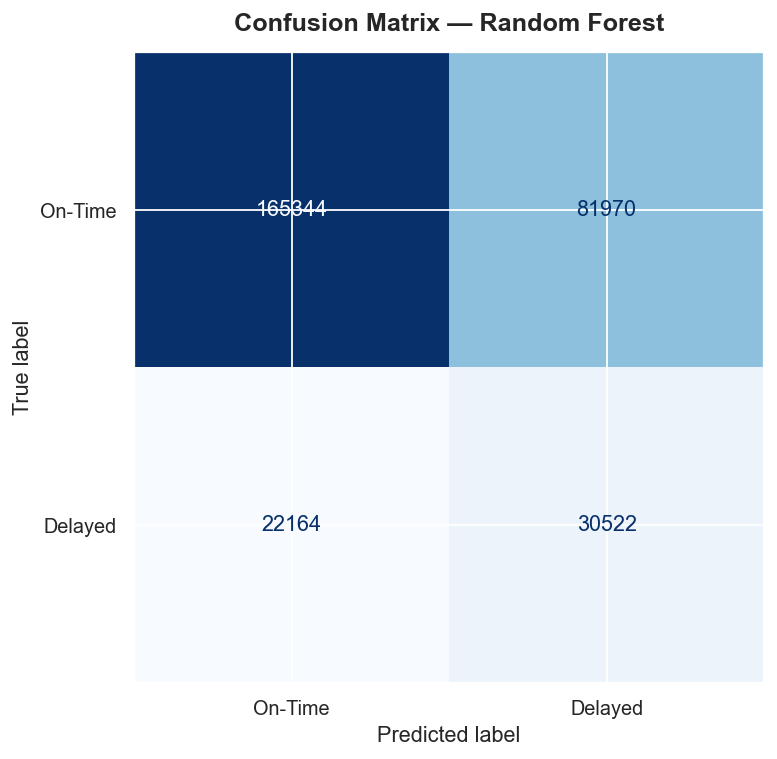

✅ Saved confusion_matrix.png


In [6]:
# --- Confusion Matrix ---
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['On-Time', 'Delayed'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Random Forest', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/confusion_matrix.png', bbox_inches='tight')
plt.show()
print('✅ Saved confusion_matrix.png')

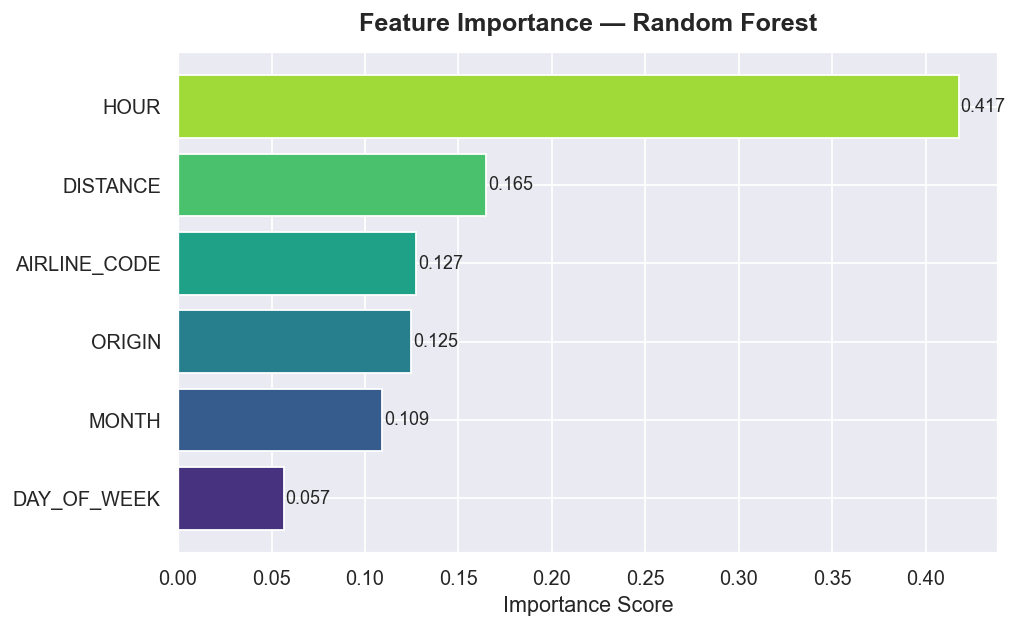

✅ Saved feature_importance.png

Feature importances:
     Feature  Importance
        HOUR    0.417492
    DISTANCE    0.164825
AIRLINE_CODE    0.127418
      ORIGIN    0.124673
       MONTH    0.109041
 DAY_OF_WEEK    0.056552


In [7]:
# --- Feature Importance ---
feat_imp = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = sns.color_palette('viridis', len(feat_imp))
ax.barh(feat_imp['Feature'], feat_imp['Importance'], color=colors, edgecolor='white')
ax.set_title('Feature Importance — Random Forest', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Importance Score', fontsize=12)
for i, (val, name) in enumerate(zip(feat_imp['Importance'], feat_imp['Feature'])):
    ax.text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/feature_importance.png', bbox_inches='tight')
plt.show()
print('✅ Saved feature_importance.png')
print('\nFeature importances:')
print(feat_imp.sort_values('Importance', ascending=False).to_string(index=False))

In [9]:
# --- Save model and encoders ---
model_path = '../models/rf_model.pkl'
joblib.dump({
    'model': model,
    'le_airline': le_airline,
    'le_origin': le_origin,
    'feature_cols': FEATURE_COLS
}, model_path)

print(f'\n✅ Model saved to: {model_path}')
print(f'   Accuracy: {acc*100:.2f}%')
print(f'   Features: {FEATURE_COLS}')


✅ Model saved to: ../models/rf_model.pkl
   Accuracy: 65.29%
   Features: ['DISTANCE', 'HOUR', 'MONTH', 'DAY_OF_WEEK', 'AIRLINE_CODE', 'ORIGIN']


In [10]:
type(model)

sklearn.ensemble._forest.RandomForestClassifier